In [30]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out
    

    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    d = a*b; d.label="d"
    e = d+c; e.label="e"
    # (a.__mul__(b)).__add__(c)
    f = Value(-2, label="f")
    L = e * f; L.label = "L"

In [31]:
e._prev

{Value(data=-6.0), Value(data=10.0)}

In [33]:
e._op

'+'

In [34]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot


In [ ]:
L.grad = 1.0

# L = e * f
# 
# Looking for dL/de = ? (it is 'f'): derivative of L with respect to d
# (f(x+h) - f(x))/h
# ((e+h)*f - e*f)/h as this is with respect to e
# (ef + hf - ef)/h
# hf/h
# f

f.grad = 4.0
e.grad = -2.0

In [49]:
# dL / dc
#
# first de / dc
# e = c + d deriving c + d with respect to c = 1.0
# 
# (f(x+h) - f(x)) / h
# (((c+h) + d) - (c + d)) / h
# (c + h + d - c - d) / h
# h/h
# 1.0

# same for de/dd

# next, use the Chain Rule: https://en.wikipedia.org/wiki/Chain_rule
# WANT:
#   dL / dc (dL / de) * (de / dc) via chain rule
#
# KNOW:
#   dL / de
#   de / dc


c.grad = e.grad * 1.0 # -2.0

d.grad = e.grad * 1.0 # -2.0



In [51]:
# dL / dd = -2.0
#
# d = a * b
# dd / da? b or -3
#
# dL / da = (dL / dd) * (dd / da) via chain rule
# 
# similar for dd / db? a or 2.0

a.grad = (-2.0)*(-3.0)
b.grad = (-2.0)*(2.0)

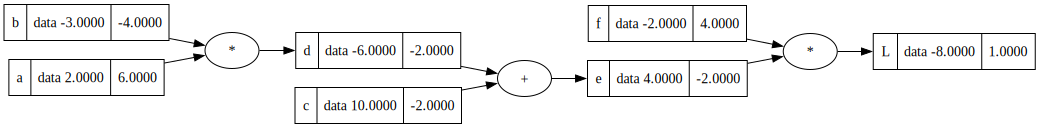

In [52]:
draw_dot(L)

In [54]:
def lol():
    h = 0.001

    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    d = a*b; d.label="d"
    e = d+c; e.label="e"
    f = Value(-2, label="f")
    L = e * f; L.label = "L"
    L1 = L.data

    a = Value(2.0, label="a")
    a.data += h  # expect a.grad = d.grad * b (or 6 as above)
    b = Value(-3.0, label="b")
    # if b.data += h  expect b.grad = d.grad * a (or -4 as above)
    c = Value(10.0, label="c")
    # if c.data += h  expect c.grad = e.grad * 1.0 (or -2 as above)
    d = a*b; d.label="d"
    # if d.data += h  expect d.grad = e.grad * 1.0 (or -2 as above)
    e = d+c; e.label="e"
    # if e.data += h  expect e.grad = f (or -2 as above)
    f = Value(-2, label="f")
    # if f.data += h  expect f.grad = e (or 4 as above)
    L = e * f; L.label = "L"
    L2 = L.data

    print((L2 - L1)/h)

lol()

6.000000000000227
